In [2]:
import argparse
from configobj import ConfigObj
import configreader as cfr
import osmnx as ox
import osmhelper as oh
from pathlib import Path
import json
import networkx as nx
import extract as ep
import igraph as ig
from timeit import default_timer as timer
from multiprocessing import Pool, cpu_count
import tqdm
import psutil
import pandas as pd
import sys
import gc
import osmqRuntime as osmqq
import osmquality as oq
import foliumhelper as fh
import folium

ModuleNotFoundError: No module named 'configreader'

In [ ]:
def get_max_speed1(cfg, edge, speeds = {}):
    #example {'osmid': 26524012, 'name': 'Gailnauer Straße',
    #  'highway': 'unclassified', 'oneway': False,
    #  'length': 31.622999999999998, 
    # 'geometry': <shapely.geometry.linestring.LineString object at 0x000001E6D0DC1100>}

    filters = cfr.get_filters(cfg)
    speed = 0
    max_speeds = []
    for filter_name, filter_values in filters.items():
        allowed_speed = speeds.get(filter_name.lower(), 0)
        if allowed_speed <= 0:
            continue
        for tag, allowed_values in filter_values.items():
            if tag in edge:
                if edge[tag] in allowed_values:
                    max_speeds.append(allowed_speed)

    if speeds["overrides"]:
        for override_name, allowed_speed in speeds["overrides"].items():
            filter = cfr.get_override_filter(cfg, override_name.capitalize())
            for key, value in filter.items():
                # print(key, value)
                if key in edge:
                    if edge[key] in value:
                        speed = allowed_speed

    if speed == 0 and max_speeds:
        speed = max(max_speeds)
        # print(max_speeds)
    return speed

In [ ]:
def get_max_speed2(g, tags_intercity, tags_local, tags_bicycle, tags_sidewalk, speeds={}):
    #example {'osmid': 26524012, 'name': 'Gailnauer Straße',
    #  'highway': 'unclassified', 'oneway': False,
    #  'length': 31.622999999999998, 
    # 'geometry': <shapely.geometry.linestring.LineString object at 0x000001E6D0DC1100>}

    # TODO Overrides
    # print(speeds)
    # input()
    # filters = cfr.get_filters(cfg)
    speed = 0
    bicycle_speed = speeds.get("bicycle", 0)
    sidewalk_speed = speeds.get("sidewalk", 0)
    primary_speed = speeds.get("intercity", 0)
    secondary_speed = speeds.get("local", 0)

    if sidewalk_speed > 0:
        for key, value in tags_sidewalk.items():
            if key in g:
                if g[key] in value:
                    speed = sidewalk_speed

    if bicycle_speed > 0:
        for key, value in tags_bicycle.items():
            if key in g:
                if g[key] in value:
                    speed = bicycle_speed

    if secondary_speed > 0:
        for key, value in tags_local.items():
            if key in g:
                if g[key] in value:
                    speed = secondary_speed

    if primary_speed > 0:
        for key, value in tags_intercity.items():
            if key in g:
                if g[key] in value:
                    speed = primary_speed

    return speed

In [ ]:
def set_speeds(G_nx, cfg = None, scenario_name = None, speed_pick = 1):
    filters = cfr.get_filters(cfg)
    tags_intercity = filters["Intercity"]
    tags_local = filters["Local"]
    tags_bicycle = filters["Bicycle"]
    tags_sidewalk = filters["Sidewalk"]
    speeds = cfr.get_speeds(cfg, scenario_name)
    # l1 =list(nx.get_edge_attributes(G_nx, "length").values())
    for u, v, k, edge in G_nx.edges(keys=True, data=True):
        # print(u,v,k,edge)
        # max_speed = get_max_speed(cfg, edge, speeds)
        max_speed1 = get_max_speed2(
                edge, tags_intercity, tags_local,
                tags_bicycle, tags_sidewalk, speeds=speeds)
        max_speed2 = get_max_speed1(cfg, edge, speeds)
        if speed_pick == 1:
            max_speed = max_speed2
        elif speed_pick == 2:
            max_speed = max_speed1
        # if not max_speed1 == max_speed2:
        #     # raise Exception("Speed did not match")
        #     print(max_speed1, max_speed2, edge)
        if max_speed == 0:
            edge['length'] = -1
        else:
            edge['length'] = edge['length'] / (max_speed / 3.6)
        
    # l2 = list(nx.get_edge_attributes(G_nx, "length").values())

    # if l1 == l2:
    #     raise Exception("Same Length with different speeds")

    # print(l1[1:10])
    # print(l2[1:10])
    
    return G_nx

In [ ]:
def analyse_scenario(city, cfg, scenario, override=False, with_speed=True, folder = None, speed_pick = 1):

    simplify = cfr.get_simplify(cfg)

    # load city
    G_nx = oh.get_place(placename=city, simplify=simplify,
                        clean_periphery=True,
                        file_identifier="", retain_all=True)

    # filter_graph by scenario
    filter_scenario = oq.get_scenario_filter(cfg, scenario["name"])

    H_nx = G_nx.copy()
    H_nx = oh.filter_graph_by_dict(H_nx, filter_scenario, drop_nodes=False)
    H_nx = oq.load_pop_scenario(
        H_nx, city, scenario["name"], simplify, override)

    H_nx = set_speeds(H_nx, cfg=cfg, scenario_name = scenario["name"], speed_pick=speed_pick)

    return H_nx

In [ ]:
cfg = ConfigObj("osmquality.ini")
scenarios = cfr.get_scenarios(cfg)
graphs1 = []
graphs2 = []
city = "Freiberg, Sachsen"
for scenario in scenarios:
    print(scenario.name)
    graph = analyse_scenario(city, cfg, scenario , override = True, speed_pick = 1)
    graph2 = analyse_scenario(city, cfg, scenario , override = True, speed_pick = 2)
    graphs1.append(graph)
    graphs2.append(graph2)

    print(len(list(nx.get_edge_attributes(graph, "length").values())))


Small
Max pop: 40708.0


c:\Users\plank\Documents\git\osmquality\Extract.py:252: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  sums = nodes.sum()


34613.38999999999
filtered: 85
Max pop: 40708.0


c:\Users\plank\Documents\git\osmquality\Extract.py:252: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  sums = nodes.sum()


34613.38999999999
filtered: 85
7250
7250
Medium
Max pop: 40708.0


...

34613.38999999999
filtered: 85
13799
13799
Optimal
Max pop: 40708.0


c:\Users\plank\Documents\git\osmquality\Extract.py:252: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  sums = nodes.sum()


34613.38999999999
filtered: 85
Max pop: 40708.0


c:\Users\plank\Documents\git\osmquality\Extract.py:252: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  sums = nodes.sum()


34613.38999999999
filtered: 85
21836
21836


Optimal


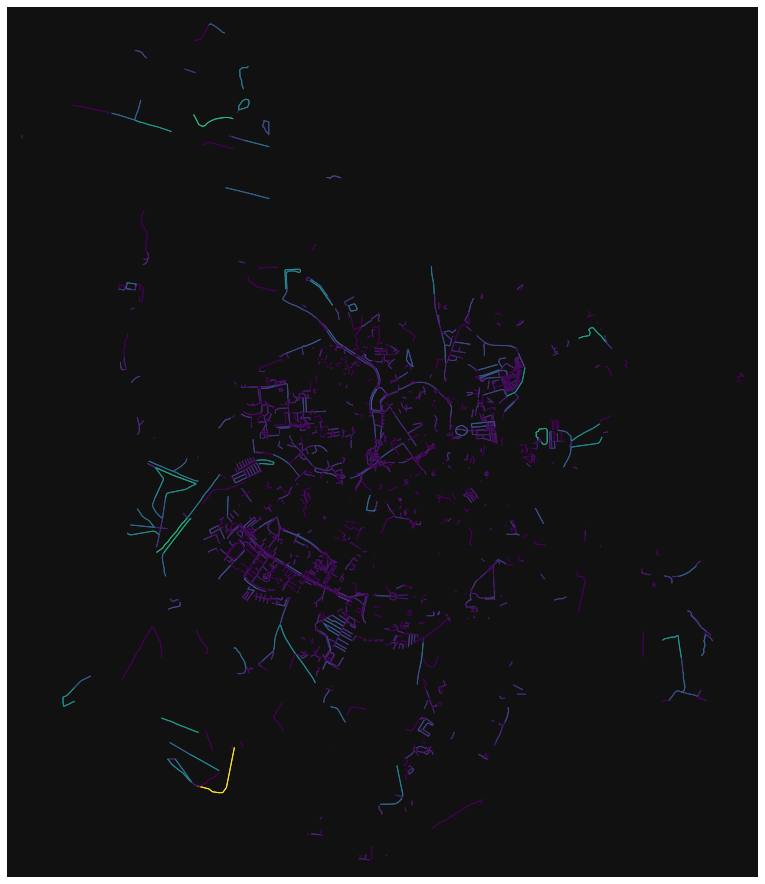

Optimal


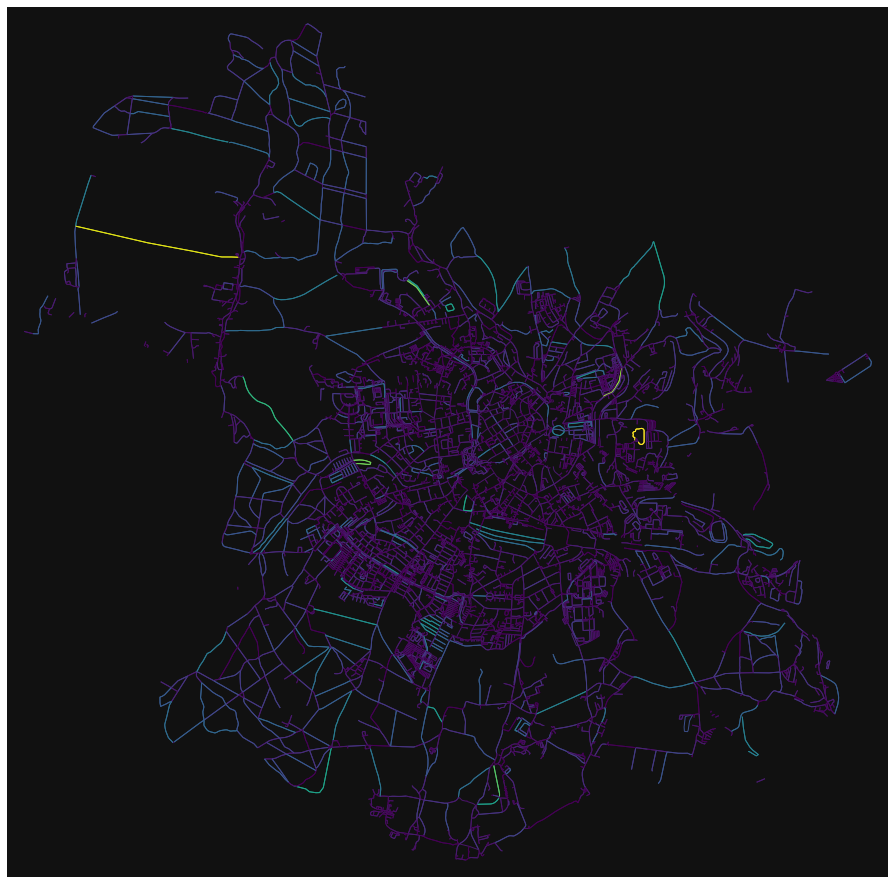

Optimal


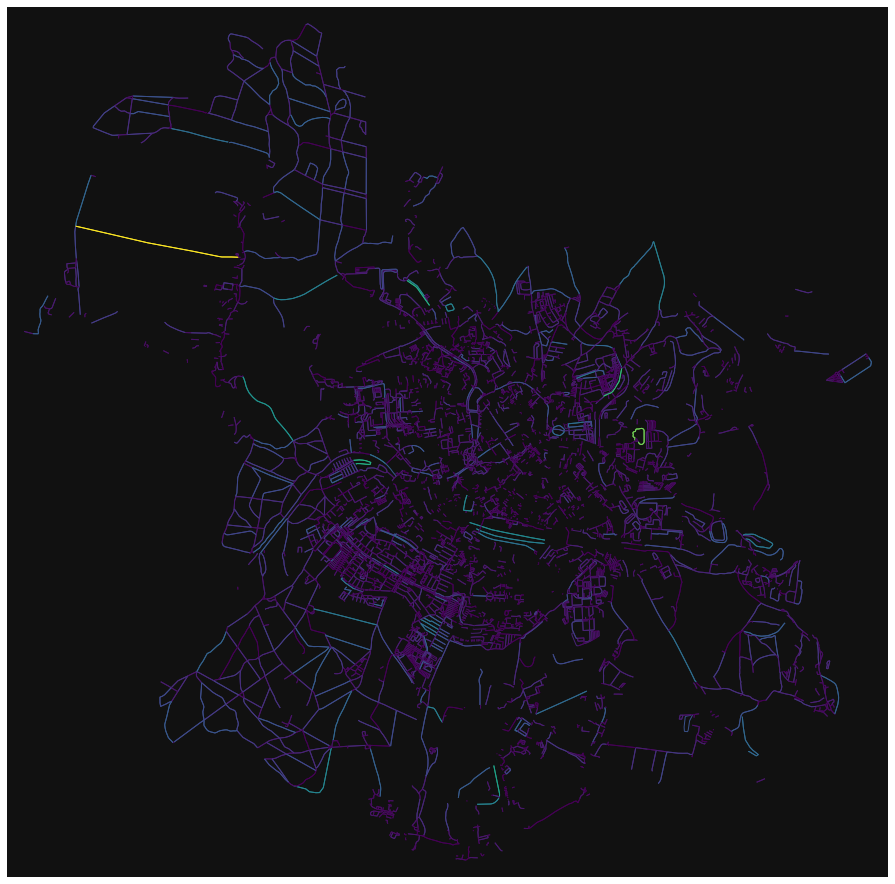

Optimal


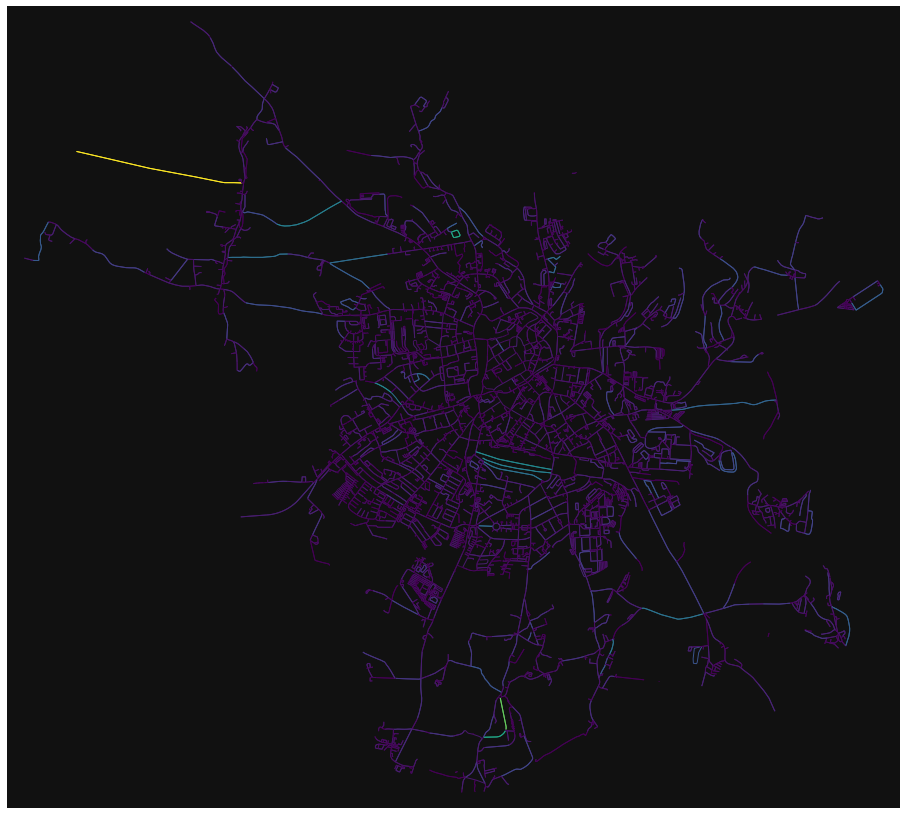

Optimal


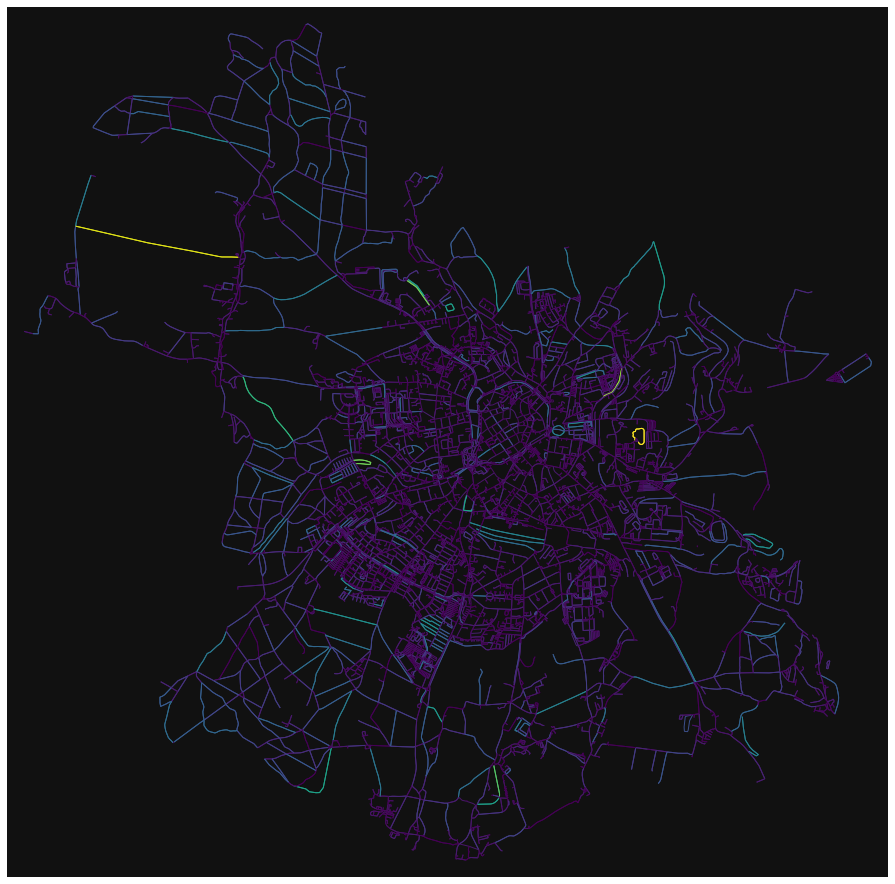

In [ ]:
for graph, scneario in zip(graphs1, scenarios):
    print(scenario["name"])
    x = ox.plot_graph(graph, figsize=(16,16), edge_color=ox.plot.get_edge_colors_by_attr(graph, "length"), node_size = 0)

Optimal


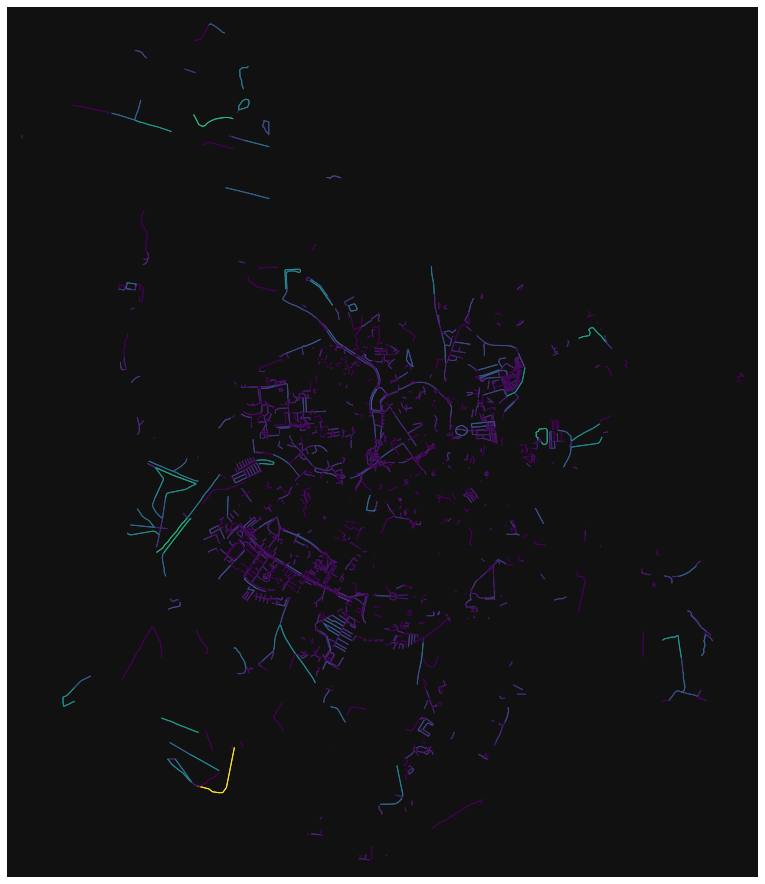

Optimal


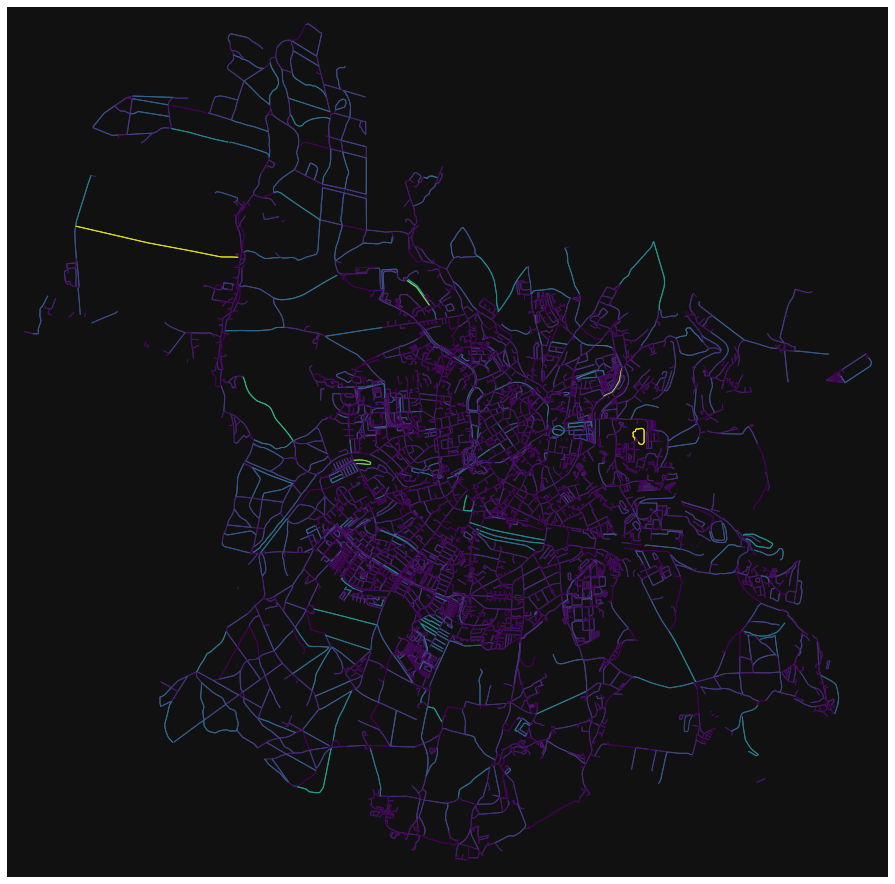

Optimal


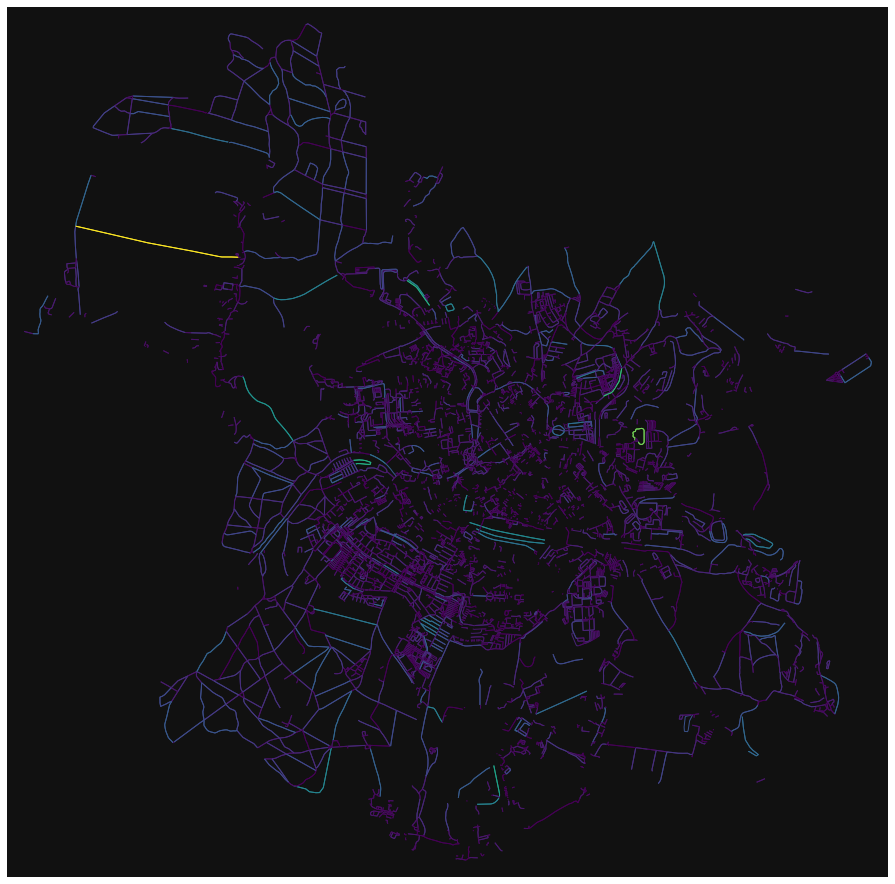

Optimal


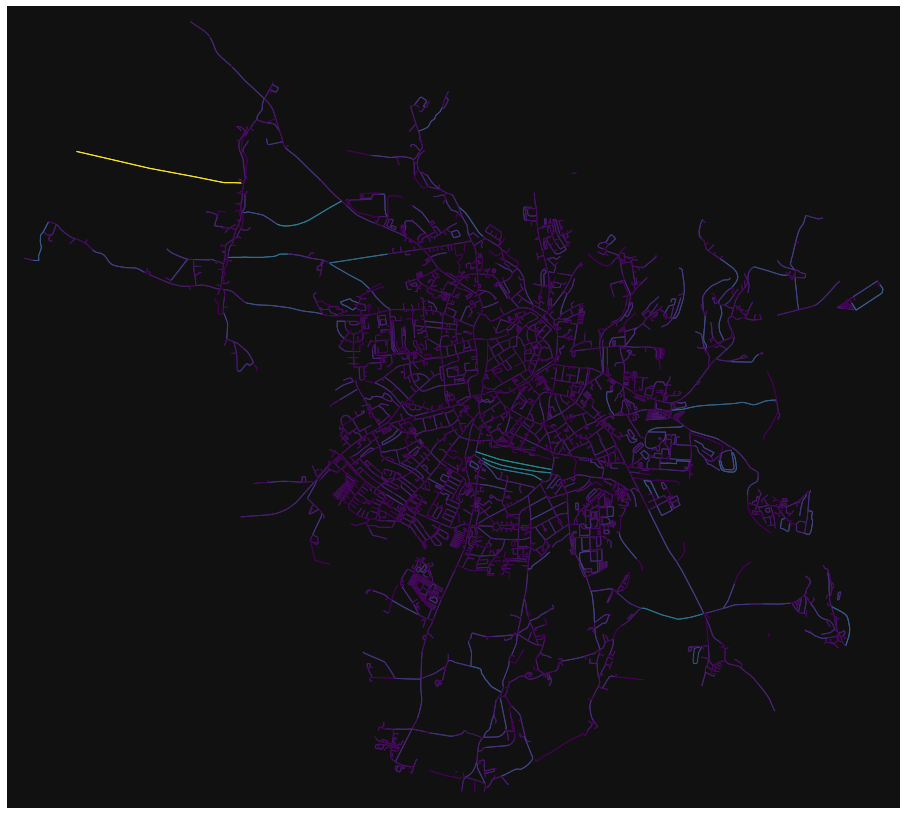

Optimal


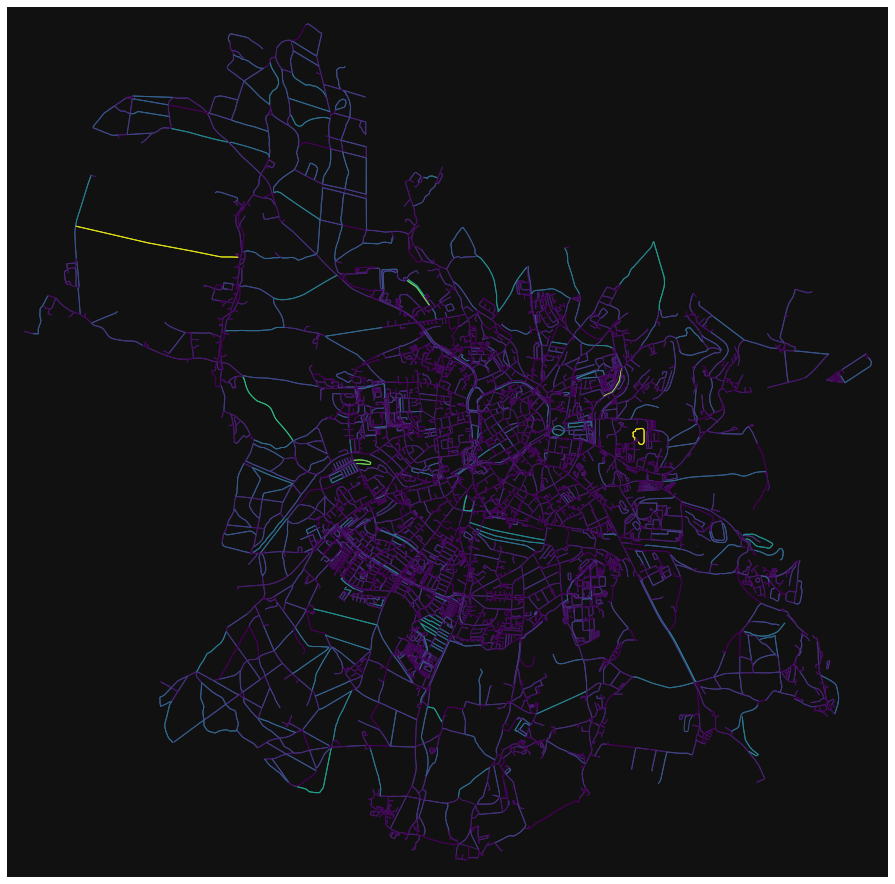

In [ ]:
for graph, scneario in zip(graphs2, scenarios):
    print(scenario["name"])
    x = ox.plot_graph(graph, figsize=(16,16), edge_color=ox.plot.get_edge_colors_by_attr(graph, "length"), node_size = 0)

In [ ]:
# x = ox.plot_graph(b, figsize=(16,16), edge_color=ox.plot.get_edge_colors_by_attr(b, "length"), node_size = 0)

In [ ]:
# l1 = list(nx.get_edge_attributes(a, "length").values())
# l2 = list(nx.get_edge_attributes(b, "length").values())

In [ ]:
# for x, y in zip(l1,l2):
#     if x == y:
#         continue
#     print(x, y)

In [ ]:
oq.get_scenario_filter(cfg, "Small")


{'sidewalk:left': ['lane',
  'both',
  'left',
  'share_busway',
  'yes',
  'right',
  'sidepath',
  'footway',
  'shared',
  'sperate'],
 'path': ['sidepath', 'sidewalk'],
 'highway': ['pedestrian', 'living_street', 'footway', 'path'],
 'foot': ['designated', 'permissive', 'yes'],
 'sidewalk:right': ['lane',
  'both',
  'left',
  'share_busway',
  'yes',
  'right',
  'sidepath',
  'footway',
  'shared',
  'sperate'],
 'sidewalk': ['right', 'seperate', 'shared', 'both', 'left', 'yes'],
 'footway': ['crossing', 'sidewalk'],
 'living_street': ['yes'],
 'sidewalk:both': ['lane',
  'both',
  'left',
  'share_busway',
  'yes',
  'right',
  'sidepath',
  'footway',
  'shared',
  'sperate']}

In [ ]:
oq.get_scenario_filter(cfg, "Medium")

{'sidewalk:left': ['lane',
  'both',
  'left',
  'share_busway',
  'yes',
  'right',
  'sidepath',
  'footway',
  'shared',
  'sperate'],
 'path': ['sidepath', 'sidewalk'],
 'living_street': ['yes'],
 'cycleway:right': ['lane',
  'both',
  'left',
  'share_busway',
  'yes',
  'right',
  'sidepath',
  'footway',
  'shared',
  'sperate'],
 'cycleway:both': ['lane',
  'both',
  'left',
  'share_busway',
  'yes',
  'right',
  'sidepath',
  'footway',
  'shared',
  'sperate'],
 'highway': ['residential',
  'pedestrian',
  'path',
  'tertiary',
  'unclassified',
  'track',
  'cycleway',
  'service',
  'footway',
  'living_street'],
 'cycleway:left': ['lane',
  'both',
  'left',
  'share_busway',
  'yes',
  'right',
  'sidepath',
  'footway',
  'shared',
  'sperate'],
 'foot': ['designated', 'permissive', 'yes'],
 'sidewalk:right': ['lane',
  'both',
  'left',
  'share_busway',
  'yes',
  'right',
  'sidepath',
  'footway',
  'shared',
  'sperate'],
 'sidewalk': ['right', 'seperate', 'shared'